In [11]:
import matplotlib.pyplot as plt
import numpy as np

In [12]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [13]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

In [14]:
def calculate_sum(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

def calculate_loss(y_true, y_pred):
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    return -np.mean(
        y_true * np.log(y_pred_clipped) + 
        (1 - y_true) * np.log(1 - y_pred_clipped)
    )

def calculate_delta(y_true, y_pred):
    return  y_pred - y_true

In [15]:
def train(X, y, layers, epochs=1000, lr=0.1):
    n_layers = len(layers)
    i_bias = 1
    i_weight = 0
    histories = []
    
    activation_functions_history = []
    
    for i in range(epochs):
        # Forward
        current_input = X
        layers_output = [X]
        layers_sum = [X]
        
        for (i, layer) in enumerate(layers):
            current_sum = calculate_sum(current_input, layer[i_weight], layer[i_bias])
            if i == n_layers - 1:
                current_input = sigmoid(current_sum)
            else:
                current_input = relu(current_sum)
            layers_sum.append(current_sum)
            layers_output.append(current_input)
        
        activation_functions_history.append([layers_sum, layers_output])

        # Backpropagation
        d_layers_output = []
        
        # Loss function and output layer delta
        delta = calculate_delta(y, layers_output[-1])
        # print(f"Epoch {i+1}/{epochs}, Loss: {calculate_loss(y, layers_output[-1]):.4f}")
        d_layers_output.append(delta)
        
        # Hidden layer propagation
        for j in range(n_layers - 1, 0, -1):
            weight = delta.dot(layers[j][i_weight].T)
            delta = weight * relu_derivative(layers_sum[j])
            d_layers_output.append(delta)
        d_layers_output.reverse()
        
        # Update weight
        for j in range(n_layers):
            layer_input = layers_output[j]
            delta_j = d_layers_output[j]
            
            layers[j][i_weight] -= layer_input.T.dot(delta_j) * lr
            layers[j][i_bias] -= np.sum(delta_j, axis=0, keepdims=True) * lr
        
        histories.append([ [w.copy(), b.copy()] for w, b in layers ])
        
    return activation_functions_history, histories, layers

In [16]:
def predict(X, layers):
    i_bias = 1
    i_weight = 0
    input_x = X
    for (j, layer) in enumerate(layers):
        print("iter", j)
        print("input: ", input_x)
        print("layer: ", layer)
        current_sum = calculate_sum(input_x, layer[i_weight], layer[i_bias])
        print("sum: ", current_sum)
        if j == len(layers) - 1:
            input_x = sigmoid(current_sum)
            print("sigmoid: ", input_x)
        else:
            input_x = relu(current_sum)
            print("relu", input_x)
    return input_x

In [17]:
np.random.seed(42)

n_input_neurons = 2
n_hidden_neurons = 4
n_output_neurons = 1

layers = []

w_hidden = np.random.uniform(size=(n_input_neurons, n_hidden_neurons))
b_hidden = np.zeros((1, n_hidden_neurons))
layers.append([w_hidden, b_hidden])

w_out = np.random.uniform(size=(n_hidden_neurons, n_output_neurons))
b_out = np.zeros((1, n_output_neurons))
layers.append([w_out, b_out])

# AND
# X = np.array([[0,0], [0,1], [1,0], [1,1]])
# y = np.array([[0], [0], [0], [1]])

# OR
# X = np.array([[0,0], [0,1], [1,0], [1,1]])
# y = np.array([[0], [1], [1], [1]])

# # XOR
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([[0], [1], [1], [0]])

activation_functions_history, histories, model = train(X, y, layers)

# print(model)

print("Predictions after training:")
predictions = predict(X, model)
for i in range(len(X)):
    print(f"""Input: {X[i]} -> Predicted: {predictions[i][0]:.4f} to {1 if predictions[i][0] > 0.5 else 0}""")

Predictions after training:
iter 0
input:  [[0 0]
 [0 1]
 [1 0]
 [1 1]]
layer:  [array([[ 1.74299359,  2.94345231,  1.53434956, -2.53376151],
       [-1.74294969, -2.94335356, -1.23643017,  2.53434076]]), array([[ 3.27671157e-04, -1.80455814e-04,  1.78022709e+00,
        -2.94107741e-04]])]
sum:  [[ 3.27671157e-04 -1.80455814e-04  1.78022709e+00 -2.94107741e-04]
 [-1.74262202e+00 -2.94353402e+00  5.43796917e-01  2.53404665e+00]
 [ 1.74332126e+00  2.94327186e+00  3.31457665e+00 -2.53405561e+00]
 [ 3.71571243e-04 -8.17078444e-05  2.07814647e+00  2.85141668e-04]]
relu [[3.27671157e-04 0.00000000e+00 1.78022709e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.43796917e-01 2.53404665e+00]
 [1.74332126e+00 2.94327186e+00 3.31457665e+00 0.00000000e+00]
 [3.71571243e-04 0.00000000e+00 2.07814647e+00 2.85141668e-04]]
iter 1
input:  [[3.27671157e-04 0.00000000e+00 1.78022709e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.43796917e-01 2.53404665e+00]
 [1.74332126e+00 2.94327186e+00 3.

In [18]:
reduction = -60
iteration = 1000
n_sample = (iteration / abs(reduction)) * (
    len(X) * n_hidden_neurons)

relu_sum = np.array([])
relu_activation = np.array([])
sigmoid_sum = np.array([])
sigmoid_activation = np.array([])
for i in range(len(activation_functions_history) -1 , len(activation_functions_history) - iteration - 1, reduction):
    relu_sum = np.append(relu_sum, np.array(activation_functions_history[i][0][1]))
    relu_activation = np.append(relu_activation, np.array(activation_functions_history[i][1][1]).flatten())
    sigmoid_sum = np.append(sigmoid_sum, np.array(activation_functions_history[i][0][2]))
    sigmoid_activation = np.append(sigmoid_activation, np.array(activation_functions_history[i][1][2]).flatten())

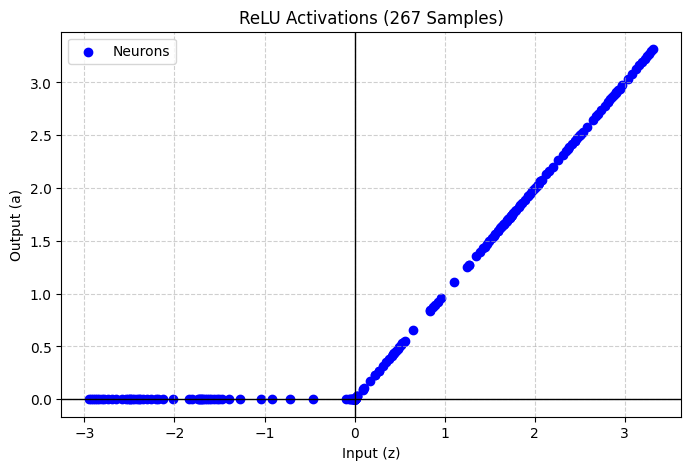

In [19]:
relu_maps = np.vstack((relu_sum, relu_activation))

plt.figure(figsize=(8, 5))
plt.scatter(relu_maps[0, :], relu_maps[1, :], color='blue', label='Neurons')

# Adding Cartesian axes for clarity
plt.axhline(0, color='black', linewidth=1) # X-axis
plt.axvline(0, color='black', linewidth=1) # Y-axis

plt.title(f"ReLU Activations ({n_sample:.0f} Samples)")
plt.xlabel("Input (z)")
plt.ylabel("Output (a)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

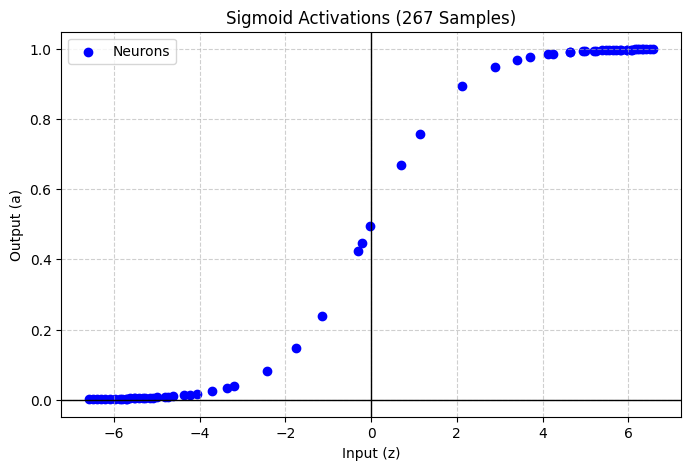

In [20]:
sigmoid_maps = np.vstack((sigmoid_sum, sigmoid_activation))

plt.figure(figsize=(8, 5))
plt.scatter(sigmoid_maps[0, :], sigmoid_maps[1, :], color='blue', label='Neurons')

# Adding Cartesian axes for clarity
plt.axhline(0, color='black', linewidth=1) # X-axis
plt.axvline(0, color='black', linewidth=1) # Y-axis

plt.title(f"Sigmoid Activations ({n_sample:.0f} Samples)")
plt.xlabel("Input (z)")
plt.ylabel("Output (a)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()